In [2]:
%%bash
set -e

pip -q install --user gdown

mkdir -p ~/work

python -m gdown "https://drive.google.com/uc?id=1idsy89m7hJ2e4NIdPlrEqgHimP0bufrb" -O ~/work/lens-finding-test.zip

ls -lh ~/work/lens-finding-test.zip


Downloading...
From (original): https://drive.google.com/uc?id=1idsy89m7hJ2e4NIdPlrEqgHimP0bufrb
m (redirected): https://drive.google.com/uc?id=1idsy89m7hJ2e4NIdPlrEqgHimP0bufrb&confirm=t&uuid=827246e8-c0b4-43fe-bee7-e2c689f28153
To: /home/jovyan/work/lens-finding-test.zip
100%|██████████| 2.11G/2.11G [00:43<00:00, 48.6MB/s]


-rw-r--r-- 1 jovyan root 2.0G Feb 10 15:11 /home/jovyan/work/lens-finding-test.zip


In [3]:
%%bash
set -e
mkdir -p ~/work/lens-finding-test
unzip -q ~/work/lens-finding-test.zip -d ~/work/lens-finding-test
ls -la ~/work/lens-finding-test | head


total 3824
drwxr-xr-x 7 jovyan root    4096 Feb 10 15:52 .
5:46 ..rwx 9 root   root    4096 Feb 10 1
drwxr-xr-x 6 jovyan root    4096 Feb 10 15:52 __MACOSX
26  2025 test_lensesroot   16384 Feb 
drwxr-xr-x 2 jovyan root 1507328 Feb 26  2025 test_nonlenses
n root  135168 Feb 26  2025 train_lenses
eswxr-xr-x 2 jovyan root 2220032 Feb 26  2025 train_nonlens


In [5]:
!pip -q install timm
!pip -q install omegaconf
!pip -q install scikit-learn
!pip -q install seaborn
!pip -q install kornia
!pip -q install escnn

In [6]:
import os
import sys
import time
import json
import glob
from datetime import datetime
from typing import Dict, Any, Optional, Tuple, List, Union

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
import timm
from tqdm.notebook import tqdm
import numpy as np
from omegaconf import OmegaConf, DictConfig
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
import kornia as K

# Try to import escnn first (newer), fall back to e2cnn
try:
    import escnn as e2cnn
    from escnn import gspaces
    USING_ESCNN = True
except ImportError:
    import e2cnn
    from e2cnn import gspaces
    USING_ESCNN = False

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ All imports successful!
PyTorch version: 2.5.1+cu124
CUDA available: True
GPU: NVIDIA H200


In [ ]:
# ============================================================
# EQUIADAPT LIBRARY CODE (INLINED)
# All required classes from equiadapt library copied here
# to make the notebook self-contained
# ============================================================

import math
from typing import Any, Dict, List, Optional, Tuple, Union

import kornia as K
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from omegaconf import DictConfig

# Try to import escnn first (newer), fall back to e2cnn
try:
    import escnn as e2cnn
    from escnn import gspaces
    USING_ESCNN = True
except ImportError:
    import e2cnn
    from e2cnn import gspaces
    USING_ESCNN = False


# ============================================================
# Common Utilities
# ============================================================

def gram_schmidt(vectors: torch.Tensor) -> torch.Tensor:
    """Applies the Gram-Schmidt process to orthogonalize a set of vectors."""
    v1 = vectors[:, 0]
    v1 = v1 / torch.norm(v1, dim=1, keepdim=True)
    v2 = vectors[:, 1] - torch.sum(vectors[:, 1] * v1, dim=1, keepdim=True) * v1
    v2 = v2 / torch.norm(v2, dim=1, keepdim=True)
    v3 = (
        vectors[:, 2]
        - torch.sum(vectors[:, 2] * v1, dim=1, keepdim=True) * v1
        - torch.sum(vectors[:, 2] * v2, dim=1, keepdim=True) * v2
    )
    v3 = v3 / torch.norm(v3, dim=1, keepdim=True)
    return torch.stack([v1, v2, v3], dim=1)


# ============================================================
# Image Utilities
# ============================================================

def roll_by_gather(feature_map: torch.Tensor, shifts: torch.Tensor) -> torch.Tensor:
    """Shifts the feature map along the group dimension."""
    device = shifts.device
    batch, channel, group, x_dim, y_dim = feature_map.shape
    arange1 = (
        torch.arange(group)
        .view((1, 1, group, 1, 1))
        .repeat((batch, channel, 1, x_dim, y_dim))
        .to(device)
    )
    arange2 = (arange1 - shifts[:, None, None, None, None].long()) % group
    return torch.gather(feature_map, 2, arange2)


def get_action_on_image_features(
    feature_map: torch.Tensor,
    group_info_dict: dict,
    group_element_dict: dict,
    induced_rep_type: str = "regular",
) -> torch.Tensor:
    """Applies a group action to the feature map."""
    num_rotations = group_info_dict["num_rotations"]
    num_group = group_info_dict["num_group"]
    assert len(feature_map.shape) == 4
    batch_size, C, H, W = feature_map.shape
    if induced_rep_type == "regular":
        assert feature_map.shape[1] % num_group == 0
        angles = group_element_dict["rotation"]
        x_out = K.geometry.rotate(feature_map, angles)

        if "reflection" in group_element_dict:
            reflect_indicator = group_element_dict["reflection"]
            x_out_reflected = K.geometry.hflip(x_out)
            x_out = x_out * reflect_indicator[:, None, None, None] + x_out_reflected * (
                1 - reflect_indicator[:, None, None, None]
            )

        x_out = x_out.reshape(batch_size, C // num_group, num_group, H, W)
        shift = angles / 360.0 * num_rotations
        if "reflection" in group_element_dict:
            x_out = torch.cat(
                [
                    roll_by_gather(x_out[:, :, :num_rotations], shift),
                    roll_by_gather(x_out[:, :, num_rotations:], -shift),
                ],
                dim=2,
            )
        else:
            x_out = roll_by_gather(x_out, shift)
        x_out = x_out.reshape(batch_size, -1, H, W)
        return x_out
    elif induced_rep_type == "scalar":
        angles = group_element_dict["rotation"]
        x_out = K.geometry.rotate(feature_map, angles)
        if "reflection" in group_element_dict:
            reflect_indicator = group_element_dict["reflection"]
            x_out_reflected = K.geometry.hflip(x_out)
            x_out = x_out * reflect_indicator[:, None, None, None] + x_out_reflected * (
                1 - reflect_indicator[:, None, None, None]
            )
        return x_out
    elif induced_rep_type == "vector":
        raise NotImplementedError("Action for vector representation is not implemented")
    else:
        raise ValueError("induced_rep_type must be regular, scalar or vector")


def flip_boxes(boxes: torch.Tensor, width: int) -> torch.Tensor:
    """Flips bounding boxes horizontally."""
    boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
    return boxes


def flip_masks(masks: torch.Tensor) -> torch.Tensor:
    """Flips masks horizontally."""
    return masks.flip(-1)


def rotate_masks(masks: torch.Tensor, angle: torch.Tensor) -> torch.Tensor:
    """Rotates masks by a specified angle."""
    return transforms.functional.rotate(masks, angle)


def rotate_points(
    origin: List[float], point: torch.Tensor, angle: torch.Tensor
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Rotates a point around an origin by a specified angle."""
    ox, oy = origin
    px, py = point
    qx = ox + torch.cos(angle) * (px - ox) - torch.sin(angle) * (py - oy)
    qy = oy + torch.sin(angle) * (px - ox) + torch.cos(angle) * (py - oy)
    return qx, qy


def rotate_boxes(boxes: torch.Tensor, angle: torch.Tensor, width: int) -> torch.Tensor:
    """Rotates bounding boxes by a specified angle."""
    origin: List[float] = [width / 2, width / 2]
    x_min_rot, y_min_rot = rotate_points(origin, boxes[:, :2].T, torch.deg2rad(angle))
    x_max_rot, y_max_rot = rotate_points(origin, boxes[:, 2:].T, torch.deg2rad(angle))
    x_min_rot, x_max_rot = torch.min(x_min_rot, x_max_rot), torch.max(x_min_rot, x_max_rot)
    y_min_rot, y_max_rot = torch.min(y_min_rot, y_max_rot), torch.max(y_min_rot, y_max_rot)
    rotated_boxes = torch.stack([x_min_rot, y_min_rot, x_max_rot, y_max_rot], dim=-1)
    return rotated_boxes


# ============================================================
# Base Canonicalization Classes
# ============================================================

class BaseCanonicalization(torch.nn.Module):
    """Base class for canonicalization."""

    def __init__(self, canonicalization_network: torch.nn.Module):
        super().__init__()
        self.canonicalization_network = canonicalization_network
        self.canonicalization_info_dict: Dict[str, torch.Tensor] = {}

    def forward(
        self, x: torch.Tensor, targets: Optional[List] = None, **kwargs: Any
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, List]]:
        return self.canonicalize(x, targets, **kwargs)

    def canonicalize(
        self, x: torch.Tensor, targets: Optional[List] = None, **kwargs: Any
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, List]]:
        raise NotImplementedError()

    def invert_canonicalization(
        self, x_canonicalized_out: torch.Tensor, **kwargs: Any
    ) -> torch.Tensor:
        raise NotImplementedError()


class IdentityCanonicalization(BaseCanonicalization):
    """Identity canonicalization (no-op)."""

    def __init__(self, canonicalization_network: torch.nn.Module = torch.nn.Identity()):
        super().__init__(canonicalization_network)

    def canonicalize(
        self, x: torch.Tensor, targets: Optional[List] = None, **kwargs: Any
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, List]]:
        if targets:
            return x, targets
        return x

    def invert_canonicalization(
        self, x_canonicalized_out: torch.Tensor, **kwargs: Any
    ) -> torch.Tensor:
        return x_canonicalized_out

    def get_prior_regularization_loss(self) -> torch.Tensor:
        return torch.tensor(0.0)

    def get_identity_metric(self) -> torch.Tensor:
        return torch.tensor(1.0)


class DiscreteGroupCanonicalization(BaseCanonicalization):
    """Discrete group canonicalization method."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        beta: float = 1.0,
        gradient_trick: str = "straight_through",
    ):
        super().__init__(canonicalization_network)
        self.beta = beta
        self.gradient_trick = gradient_trick

    def groupactivations_to_groupelementonehot(
        self, group_activations: torch.Tensor
    ) -> torch.Tensor:
        group_activations_one_hot = torch.nn.functional.one_hot(
            torch.argmax(group_activations, dim=-1), self.num_group
        ).float()
        group_activations_soft = torch.nn.functional.softmax(
            self.beta * group_activations, dim=-1
        )
        if self.gradient_trick == "straight_through":
            if self.training:
                group_element_onehot = (
                    group_activations_one_hot
                    + group_activations_soft
                    - group_activations_soft.detach()
                )
            else:
                group_element_onehot = group_activations_one_hot
        elif self.gradient_trick == "gumbel_softmax":
            group_element_onehot = torch.nn.functional.gumbel_softmax(
                group_activations, tau=1, hard=True
            )
        else:
            raise ValueError(f"Gradient trick {self.gradient_trick} not implemented")
        return group_element_onehot

    def get_prior_regularization_loss(self) -> torch.Tensor:
        group_activations = self.canonicalization_info_dict["group_activations"]
        dataset_prior = torch.zeros((group_activations.shape[0],), dtype=torch.long).to(
            self.device
        )
        return torch.nn.CrossEntropyLoss()(group_activations, dataset_prior)

    def get_identity_metric(self) -> torch.Tensor:
        group_activations = self.canonicalization_info_dict["group_activations"]
        return (group_activations.argmax(dim=-1) == 0).float().mean()


class ContinuousGroupCanonicalization(BaseCanonicalization):
    """Continuous group canonicalization method."""

    def __init__(self, canonicalization_network: torch.nn.Module, beta: float = 1.0):
        super().__init__(canonicalization_network)
        self.beta = beta

    def get_prior_regularization_loss(self) -> torch.Tensor:
        group_elements_rep = self.canonicalization_info_dict[
            "group_element_matrix_representation"
        ]
        dataset_prior = (
            torch.eye(group_elements_rep.shape[-1])
            .repeat(group_elements_rep.shape[0], 1, 1)
            .to(self.device)
        )
        return torch.nn.MSELoss()(group_elements_rep, dataset_prior)

    def get_identity_metric(self) -> torch.Tensor:
        group_elements_rep = self.canonicalization_info_dict[
            "group_element_matrix_representation"
        ]
        identity_element = (
            torch.eye(group_elements_rep.shape[-1])
            .repeat(group_elements_rep.shape[0], 1, 1)
            .to(self.device)
        )
        return (
            1.0
            - torch.nn.functional.mse_loss(group_elements_rep, identity_element).mean()
        )


# ============================================================
# Custom Equivariant Layers (Kornia-based)
# ============================================================

class RotationEquivariantConvLift(nn.Module):
    """Rotation equivariant convolutional layer with lifting."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        num_rotations: int = 4,
        stride: int = 1,
        padding: int = 0,
        bias: bool = True,
        device: str = "cuda",
    ):
        super().__init__()
        self.weights = nn.Parameter(
            torch.empty(out_channels, in_channels, kernel_size, kernel_size).to(device)
        )
        torch.nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_channels).to(device))
            torch.nn.init.zeros_(self.bias)
        else:
            self.bias = None
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.stride = stride
        self.padding = padding
        self.num_rotations = num_rotations
        self.kernel_size = kernel_size

    def get_rotated_weights(
        self, weights: torch.Tensor, num_rotations: int = 4
    ) -> torch.Tensor:
        device = weights.device
        weights = weights.flatten(0, 1).unsqueeze(0).repeat(num_rotations, 1, 1, 1)
        rotated_weights = K.geometry.rotate(
            weights,
            torch.linspace(0.0, 360.0, steps=num_rotations + 1, dtype=torch.float32)[
                :num_rotations
            ].to(device),
        )
        rotated_weights = rotated_weights.reshape(
            self.num_rotations,
            self.out_channels,
            self.in_channels,
            self.kernel_size,
            self.kernel_size,
        ).transpose(0, 1)
        return rotated_weights.flatten(0, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        rotated_weights = self.get_rotated_weights(self.weights, self.num_rotations)
        x = F.conv2d(x, rotated_weights, stride=self.stride, padding=self.padding)
        x = x.reshape(
            batch_size, self.out_channels, self.num_rotations, x.shape[2], x.shape[3]
        )
        if self.bias is not None:
            x = x + self.bias[None, :, None, None, None]
        return x


class RotoReflectionEquivariantConvLift(nn.Module):
    """Roto-reflection equivariant convolutional layer with lifting."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        num_rotations: int = 4,
        stride: int = 1,
        padding: int = 0,
        bias: bool = True,
        device: str = "cuda",
    ):
        super().__init__()
        num_group_elements = 2 * num_rotations
        self.weights = nn.Parameter(
            torch.empty(out_channels, in_channels, kernel_size, kernel_size).to(device)
        )
        torch.nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_channels).to(device))
            torch.nn.init.zeros_(self.bias)
        else:
            self.bias = None
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.stride = stride
        self.padding = padding
        self.num_rotations = num_rotations
        self.kernel_size = kernel_size
        self.num_group_elements = num_group_elements

    def get_rotoreflected_weights(
        self, weights: torch.Tensor, num_rotations: int = 4
    ) -> torch.Tensor:
        device = weights.device
        weights = weights.flatten(0, 1).unsqueeze(0).repeat(num_rotations, 1, 1, 1)
        rotated_weights = K.geometry.rotate(
            weights,
            torch.linspace(0.0, 360.0, steps=num_rotations + 1, dtype=torch.float32)[
                :num_rotations
            ].to(device),
        )
        reflected_weights = K.geometry.hflip(rotated_weights)
        rotoreflected_weights = torch.cat([rotated_weights, reflected_weights], dim=0)
        rotoreflected_weights = rotoreflected_weights.reshape(
            self.num_group_elements,
            self.out_channels,
            self.in_channels,
            self.kernel_size,
            self.kernel_size,
        ).transpose(0, 1)
        return rotoreflected_weights.flatten(0, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        rotoreflected_weights = self.get_rotoreflected_weights(
            self.weights, self.num_rotations
        )
        x = F.conv2d(x, rotoreflected_weights, stride=self.stride, padding=self.padding)
        x = x.reshape(
            batch_size,
            self.out_channels,
            self.num_group_elements,
            x.shape[2],
            x.shape[3],
        )
        if self.bias is not None:
            x = x + self.bias[None, :, None, None, None]
        return x


class RotationEquivariantConv(nn.Module):
    """Rotation equivariant convolutional layer."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        num_rotations: int = 4,
        stride: int = 1,
        padding: int = 0,
        bias: bool = True,
        device: str = "cuda",
    ):
        super().__init__()
        self.weights = nn.Parameter(
            torch.empty(
                out_channels, in_channels, num_rotations, kernel_size, kernel_size
            ).to(device)
        )
        torch.nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_channels).to(device))
            torch.nn.init.zeros_(self.bias)
        else:
            self.bias = None
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.stride = stride
        self.padding = padding
        self.num_rotations = num_rotations
        self.kernel_size = kernel_size
        indices = (
            torch.arange(num_rotations)
            .view((1, 1, num_rotations, 1, 1))
            .repeat(
                num_rotations, out_channels * in_channels, 1, kernel_size, kernel_size
            )
        )
        self.permute_indices_along_group = (
            (indices - torch.arange(num_rotations)[:, None, None, None, None])
            % num_rotations
        ).to(device)
        self.angle_list = torch.linspace(
            0.0, 360.0, steps=num_rotations + 1, dtype=torch.float32
        )[:num_rotations].to(device)

    def get_rotated_permuted_weights(
        self, weights: torch.Tensor, num_rotations: int = 4
    ) -> torch.Tensor:
        weights = weights.flatten(0, 1).unsqueeze(0).repeat(num_rotations, 1, 1, 1, 1)
        permuted_weights = torch.gather(weights, 2, self.permute_indices_along_group)
        rotated_permuted_weights = K.geometry.rotate(
            permuted_weights.flatten(1, 2),
            self.angle_list,
        )
        rotated_permuted_weights = (
            rotated_permuted_weights.reshape(
                self.num_rotations,
                self.out_channels,
                self.in_channels,
                self.num_rotations,
                self.kernel_size,
                self.kernel_size,
            )
            .transpose(0, 1)
            .reshape(
                self.out_channels * self.num_rotations,
                self.in_channels * self.num_rotations,
                self.kernel_size,
                self.kernel_size,
            )
        )
        return rotated_permuted_weights

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        x = x.flatten(1, 2)
        rotated_permuted_weights = self.get_rotated_permuted_weights(
            self.weights, self.num_rotations
        )
        x = F.conv2d(
            x, rotated_permuted_weights, stride=self.stride, padding=self.padding
        )
        x = x.reshape(
            batch_size, self.out_channels, self.num_rotations, x.shape[2], x.shape[3]
        )
        if self.bias is not None:
            x = x + self.bias[None, :, None, None, None]
        return x


class RotoReflectionEquivariantConv(nn.Module):
    """Roto-reflection equivariant convolutional layer."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        num_rotations: int = 4,
        stride: int = 1,
        padding: int = 0,
        bias: bool = True,
        device: str = "cuda",
    ):
        super().__init__()
        num_group_elements: int = 2 * num_rotations
        self.weights = nn.Parameter(
            torch.empty(
                out_channels, in_channels, num_group_elements, kernel_size, kernel_size
            ).to(device)
        )
        torch.nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_channels).to(device))
            torch.nn.init.zeros_(self.bias)
        else:
            self.bias = None
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.stride = stride
        self.padding = padding
        self.num_rotations = num_rotations
        self.kernel_size = kernel_size
        self.num_group_elements = num_group_elements
        indices = (
            torch.arange(num_rotations)
            .view((1, 1, num_rotations, 1, 1))
            .repeat(
                num_rotations, out_channels * in_channels, 1, kernel_size, kernel_size
            )
        )
        self.permute_indices_along_group = (
            indices - torch.arange(num_rotations)[:, None, None, None, None]
        ) % num_rotations
        self.permute_indices_along_group_inverse = (
            indices + torch.arange(num_rotations)[:, None, None, None, None]
        ) % num_rotations
        self.permute_indices_upper_half = torch.cat(
            [
                self.permute_indices_along_group,
                self.permute_indices_along_group_inverse + num_rotations,
            ],
            dim=2,
        )
        self.permute_indices_lower_half = torch.cat(
            [
                self.permute_indices_along_group_inverse + num_rotations,
                self.permute_indices_along_group,
            ],
            dim=2,
        )
        self.permute_indices = torch.cat(
            [self.permute_indices_upper_half, self.permute_indices_lower_half], dim=0
        ).to(device)
        self.angle_list = torch.cat(
            [
                torch.linspace(
                    0.0, 360.0, steps=num_rotations + 1, dtype=torch.float32
                )[:num_rotations],
                torch.linspace(
                    0.0, 360.0, steps=num_rotations + 1, dtype=torch.float32
                )[:num_rotations],
            ]
        ).to(device)

    def get_rotoreflected_permuted_weights(
        self, weights: torch.Tensor, num_rotations: int = 4
    ) -> torch.Tensor:
        weights = (
            weights.flatten(0, 1)
            .unsqueeze(0)
            .repeat(self.num_group_elements, 1, 1, 1, 1)
        )
        permuted_weights = torch.gather(weights, 2, self.permute_indices)
        rotated_permuted_weights = K.geometry.rotate(
            permuted_weights.flatten(1, 2), self.angle_list
        )
        rotoreflected_permuted_weights = torch.cat(
            [
                rotated_permuted_weights[: self.num_rotations],
                K.geometry.hflip(rotated_permuted_weights[self.num_rotations :]),
            ]
        )
        rotoreflected_permuted_weights = (
            rotoreflected_permuted_weights.reshape(
                self.num_group_elements,
                self.out_channels,
                self.in_channels,
                self.num_group_elements,
                self.kernel_size,
                self.kernel_size,
            )
            .transpose(0, 1)
            .reshape(
                self.out_channels * self.num_group_elements,
                self.in_channels * self.num_group_elements,
                self.kernel_size,
                self.kernel_size,
            )
        )
        return rotoreflected_permuted_weights

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        x = x.flatten(1, 2)
        rotoreflected_permuted_weights = self.get_rotoreflected_permuted_weights(
            self.weights, self.num_rotations
        )
        x = F.conv2d(
            x, rotoreflected_permuted_weights, stride=self.stride, padding=self.padding
        )
        x = x.reshape(
            batch_size,
            self.out_channels,
            self.num_group_elements,
            x.shape[2],
            x.shape[3],
        )
        if self.bias is not None:
            x = x + self.bias[None, :, None, None, None]
        return x


# ============================================================
# Custom Equivariant Network (Kornia-based)
# ============================================================

class CustomEquivariantNetwork(nn.Module):
    """Custom equivariant network using Kornia-based layers."""

    def __init__(
        self,
        in_shape: Tuple[int, int, int],
        out_channels: int,
        kernel_size: int,
        group_type: str = "rotation",
        num_rotations: int = 4,
        num_layers: int = 1,
        device: str = "cuda" if torch.cuda.is_available() else "cpu",
    ):
        super().__init__()
        
        self.group_type = group_type
        self.num_rotations = num_rotations

        if group_type == "rotation":
            layer_list = [
                RotationEquivariantConvLift(
                    in_shape[0], out_channels, kernel_size, num_rotations, device=device
                )
            ]
            for i in range(num_layers - 1):
                layer_list.append(nn.ReLU())
                layer_list.append(
                    RotationEquivariantConv(
                        out_channels, out_channels, 1, num_rotations, device=device
                    )
                )
            self.eqv_network = nn.Sequential(*layer_list)
        elif group_type == "roto-reflection":
            layer_list = [
                RotoReflectionEquivariantConvLift(
                    in_shape[0], out_channels, kernel_size, num_rotations, device=device
                )
            ]
            for i in range(num_layers - 1):
                layer_list.append(nn.ReLU())
                layer_list.append(
                    RotoReflectionEquivariantConv(
                        out_channels, out_channels, 1, num_rotations, device=device
                    )
                )
            self.eqv_network = nn.Sequential(*layer_list)
        else:
            raise ValueError("group_type must be rotation or roto-reflection for now.")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feature_map = self.eqv_network(x)
        group_activations = torch.mean(feature_map, dim=(1, 3, 4))
        return group_activations


# ============================================================
# ESCNN-based Networks
# ============================================================

class ESCNNEquivariantNetwork(torch.nn.Module):
    """Equivariant CNN using ESCNN/E2CNN library."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int,
        kernel_size: int,
        group_type: str = "rotation",
        num_rotations: int = 4,
        num_layers: int = 1,
    ):
        super().__init__()

        self.in_channels = in_shape[0]
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.group_type = group_type
        self.num_rotations = num_rotations

        if group_type == "rotation":
            self.gspace = gspaces.Rot2dOnR2(num_rotations)
        elif group_type == "roto-reflection":
            self.gspace = gspaces.FlipRot2dOnR2(num_rotations)
        else:
            raise ValueError("group_type must be rotation or roto-reflection for now.")

        self.num_group_elements = (
            num_rotations if group_type == "rotation" else 2 * num_rotations
        )

        r1 = e2cnn.nn.FieldType(
            self.gspace, [self.gspace.trivial_repr] * self.in_channels
        )
        r2 = e2cnn.nn.FieldType(self.gspace, [self.gspace.regular_repr] * out_channels)

        self.in_type = r1
        self.out_type = r2

        modules = [
            e2cnn.nn.R2Conv(self.in_type, self.out_type, kernel_size),
            e2cnn.nn.InnerBatchNorm(self.out_type, momentum=0.9),
            e2cnn.nn.ReLU(self.out_type, inplace=True),
            e2cnn.nn.PointwiseDropout(self.out_type, p=0.5),
        ]
        for _ in range(num_layers - 2):
            modules.append(
                e2cnn.nn.R2Conv(self.out_type, self.out_type, kernel_size),
            )
            modules.append(
                e2cnn.nn.InnerBatchNorm(self.out_type, momentum=0.9),
            )
            modules.append(
                e2cnn.nn.ReLU(self.out_type, inplace=True),
            )
            modules.append(
                e2cnn.nn.PointwiseDropout(self.out_type, p=0.5),
            )

        modules.append(
            e2cnn.nn.R2Conv(self.out_type, self.out_type, kernel_size),
        )

        self.eqv_network = e2cnn.nn.SequentialModule(*modules)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = e2cnn.nn.GeometricTensor(x, self.in_type)
        out = self.eqv_network(x)

        feature_map = out.tensor
        feature_map = feature_map.reshape(
            feature_map.shape[0],
            self.out_channels,
            self.num_group_elements,
            feature_map.shape[-2],
            feature_map.shape[-1],
        )

        group_activations = torch.mean(feature_map, dim=(1, 3, 4))

        return group_activations


class ESCNNSteerableNetwork(torch.nn.Module):
    """Steerable Equivariant CNN for continuous rotation equivariance."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int,
        kernel_size: int = 9,
        group_type: str = "rotation",
        num_layers: int = 1,
        maximum_frequency: int = 6,
    ):
        super().__init__()

        self.group_type = group_type
        assert group_type == "rotation", "group_type must be rotation for now."

        self.gspace = gspaces.Rot2dOnR2(N=-1, maximum_frequency=maximum_frequency)

        in_type = e2cnn.nn.FieldType(
            self.gspace, in_shape[0] * [self.gspace.trivial_repr]
        )

        self.in_type = in_type

        modules = []

        max_freq = min(3, maximum_frequency)
        hidden_irreps = [self.gspace.irrep(f) for f in range(1, max_freq + 1)]
        
        for i in range(num_layers):
            out_type = e2cnn.nn.FieldType(
                self.gspace, 
                out_channels * hidden_irreps
            )
            
            modules.append(
                e2cnn.nn.R2Conv(
                    in_type,
                    out_type,
                    kernel_size=kernel_size,
                    padding=kernel_size // 2,
                    bias=False,
                )
            )
            
            modules.append(e2cnn.nn.NormBatchNorm(out_type))
            modules.append(e2cnn.nn.NormNonLinearity(out_type, function='n_relu'))
            
            in_type = out_type

        out_type = e2cnn.nn.FieldType(
            self.gspace, [self.gspace.irrep(1), self.gspace.irrep(1)]
        )
        modules.append(
            e2cnn.nn.R2Conv(
                in_type, out_type, kernel_size=kernel_size, padding=0, bias=False
            )
        )

        self.block = e2cnn.nn.SequentialModule(*modules)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = e2cnn.nn.GeometricTensor(x, self.in_type)
        out = self.block(x)

        feature_maps = out.tensor
        feature_maps = torch.mean(feature_maps, dim=(-1, -2))
        feature_maps = feature_maps.reshape(feature_maps.shape[0], 2, 2)
        return feature_maps


class ESCNNWideBottleneck(e2cnn.nn.EquivariantModule):
    """Wide bottleneck layer for Equivariant CNN."""

    def __init__(
        self,
        in_type: e2cnn.nn.FieldType,
        middle_type: e2cnn.nn.FieldType,
        out_type: e2cnn.nn.FieldType,
        kernel_size: int = 3,
    ):
        super().__init__()
        self.in_type = in_type
        self.middle_type = middle_type
        self.out_type = out_type
        self.kernel_size = kernel_size

        self.conv_network = e2cnn.nn.SequentialModule(
            e2cnn.nn.R2Conv(self.in_type, self.middle_type, 1),
            e2cnn.nn.InnerBatchNorm(self.middle_type, momentum=0.9),
            e2cnn.nn.ReLU(self.middle_type, inplace=True),
            e2cnn.nn.R2Conv(
                self.middle_type, self.out_type, kernel_size, padding=kernel_size // 2
            ),
            e2cnn.nn.InnerBatchNorm(self.out_type, momentum=0.9),
            e2cnn.nn.ReLU(self.out_type, inplace=True),
            e2cnn.nn.R2Conv(self.out_type, self.in_type, 1),
        )

    def forward(self, x: e2cnn.nn.GeometricTensor) -> e2cnn.nn.GeometricTensor:
        out = self.conv_network(x)
        out += x
        return out

    def evaluate_output_shape(self, input_shape: Tuple[int]) -> Tuple[int]:
        return self.forward(input_shape).tensor.shape


class ESCNNWideBasic(e2cnn.nn.EquivariantModule):
    """Wide basic layer for Equivariant CNN."""

    def __init__(
        self,
        in_type: e2cnn.nn.FieldType,
        middle_type: e2cnn.nn.FieldType,
        out_type: e2cnn.nn.FieldType,
        kernel_size: int = 3,
    ):
        super().__init__()
        self.in_type = in_type
        self.middle_type = middle_type
        self.out_type = out_type
        self.kernel_size = kernel_size

        self.conv_network = e2cnn.nn.SequentialModule(
            e2cnn.nn.R2Conv(self.in_type, self.middle_type, kernel_size),
            e2cnn.nn.InnerBatchNorm(self.middle_type, momentum=0.9),
            e2cnn.nn.ReLU(self.middle_type, inplace=True),
            e2cnn.nn.R2Conv(self.middle_type, self.out_type, kernel_size),
        )

        self.shortcut = None
        if self.in_type != self.out_type:
            self.shortcut = e2cnn.nn.SequentialModule(
                e2cnn.nn.R2Conv(self.in_type, self.out_type, 2 * kernel_size - 1),
            )

    def forward(self, x: e2cnn.nn.GeometricTensor) -> e2cnn.nn.GeometricTensor:
        out = self.conv_network(x)
        shortcut = self.shortcut(x) if self.shortcut is not None else x
        out += shortcut
        return out

    def evaluate_output_shape(self, input_shape: Tuple[int]) -> Tuple[int]:
        return self.forward(input_shape).tensor.shape


class ESCNNWRNEquivariantNetwork(torch.nn.Module):
    """Wide Residual Network that is equivariant under rotations or roto-reflections."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int = 64,
        kernel_size: int = 9,
        group_type: str = "rotation",
        num_layers: int = 12,
        num_rotations: int = 4,
    ):
        super().__init__()

        self.group_type = group_type

        if group_type == "rotation":
            self.gspace = gspaces.Rot2dOnR2(num_rotations)
        elif group_type == "roto-reflection":
            self.gspace = gspaces.FlipRot2dOnR2(num_rotations)
        else:
            raise ValueError("group_type must be rotation or roto-reflection for now.")

        widen_factor = 2
        self.kernel_size = kernel_size
        self.group_type = group_type
        self.out_channels = out_channels * widen_factor

        self.num_rotations = num_rotations
        self.num_group_elements = (
            num_rotations if group_type == "rotation" else 2 * num_rotations
        )

        nstages = [
            out_channels // 4,
            out_channels // 4 * widen_factor,
            out_channels // 2 * widen_factor,
            out_channels * widen_factor,
        ]
        r1 = e2cnn.nn.FieldType(self.gspace, [self.gspace.trivial_repr] * in_shape[0])
        r2 = e2cnn.nn.FieldType(self.gspace, [self.gspace.regular_repr] * nstages[0])
        r3 = e2cnn.nn.FieldType(self.gspace, [self.gspace.regular_repr] * nstages[1])
        r4 = e2cnn.nn.FieldType(self.gspace, [self.gspace.regular_repr] * nstages[2])
        r5 = e2cnn.nn.FieldType(self.gspace, [self.gspace.regular_repr] * nstages[3])

        self.in_type = r1
        self.out_type = r5

        modules = [
            e2cnn.nn.R2Conv(r1, r2, kernel_size),
            e2cnn.nn.InnerBatchNorm(r2, momentum=0.9),
            e2cnn.nn.ReLU(r2, inplace=True),
        ]

        repetitions = max(1, num_layers // 3)
        rs = (
            [r2] * repetitions
            + [r3] * repetitions
            + [r4] * repetitions
        )
        for ridx in range(num_layers - 1):
            if ridx >= len(rs) - 1:
                break
            if ridx % repetitions == repetitions - 1:
                modules.append(
                    ESCNNWideBasic(rs[ridx], rs[ridx + 1], rs[ridx + 1], kernel_size),
                )
                modules.append(
                    e2cnn.nn.InnerBatchNorm(rs[ridx + 1], momentum=0.9),
                )
                modules.append(
                    e2cnn.nn.ReLU(rs[ridx + 1], inplace=True),
                )
            else:
                modules.append(
                    ESCNNWideBottleneck(
                        rs[ridx], rs[ridx + 1], rs[ridx + 1], kernel_size
                    ),
                )
                modules.append(
                    e2cnn.nn.InnerBatchNorm(rs[ridx + 1], momentum=0.9),
                )
                modules.append(
                    e2cnn.nn.ReLU(rs[ridx + 1], inplace=True),
                )

        last_type = rs[min(num_layers - 1, len(rs) - 1)] if rs else r2
        
        modules.append(
            e2cnn.nn.R2Conv(last_type, r5, kernel_size),
        )

        self.eqv_network = e2cnn.nn.SequentialModule(*modules)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = e2cnn.nn.GeometricTensor(x, self.in_type)
        out = self.eqv_network(x)

        feature_map = out.tensor
        feature_map = feature_map.reshape(
            feature_map.shape[0],
            feature_map.shape[1] // self.num_group_elements,
            self.num_group_elements,
            feature_map.shape[-2],
            feature_map.shape[-1],
        )
        feature_fibres = torch.mean(feature_map, dim=(1, 3, 4))

        return feature_fibres


# ============================================================
# Non-Equivariant Networks
# ============================================================

class ConvNetwork(nn.Module):
    """Standard convolutional neural network."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int,
        kernel_size: int,
        num_layers: int = 2,
        out_vector_size: int = 128,
    ):
        super().__init__()

        in_channels = in_shape[0]
        layers: List[nn.Module] = []
        for i in range(num_layers):
            if i == 0:
                layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, 2))
            elif i % 3 == 2:
                layers.append(
                    nn.Conv2d(out_channels, 2 * out_channels, kernel_size, 2, 1)
                )
                out_channels *= 2
            else:
                layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, 2))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.GELU())

        self.enc_network = nn.Sequential(*layers)
        out_shape = self.enc_network(torch.zeros(1, *in_shape)).shape

        out_dim = out_shape[1] * out_shape[2] * out_shape[3]
        self.final_fc = nn.Sequential(
            nn.BatchNorm1d(out_dim),
            nn.Dropout1d(0.5),
            nn.ReLU(),
            nn.Linear(out_dim, out_vector_size),
        )
        self.out_vector_size = out_vector_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        out = self.enc_network(x)
        out = out.reshape(batch_size, -1)
        return self.final_fc(out)


class ResNet18Network(nn.Module):
    """Neural network based on ResNet-18 architecture."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int = 32,
        kernel_size: int = 7,
        num_layers: int = 2,
        out_vector_size: int = 128,
    ):
        super().__init__()
        import torchvision
        self.resnet18 = torchvision.models.resnet18(weights="DEFAULT")
        self.resnet18.fc = nn.Sequential(
            nn.Linear(512, out_vector_size),
        )
        self.out_vector_size = out_vector_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.resnet18(x)


class WideResNet101Network(nn.Module):
    """Neural network based on WideResNet-101 architecture."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int = 32,
        kernel_size: int = 7,
        num_layers: int = 2,
        out_vector_size: int = 128,
    ):
        super().__init__()
        import torchvision
        self.wideresnet = torchvision.models.wide_resnet101_2(weights="DEFAULT")
        self.wideresnet.fc = nn.Sequential(
            nn.Linear(2048, out_vector_size),
        )
        self.out_vector_size = out_vector_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.wideresnet(x)


class WideResNet50Network(nn.Module):
    """Neural network based on WideResNet-50 architecture."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int = 32,
        kernel_size: int = 7,
        num_layers: int = 2,
        out_vector_size: int = 128,
    ):
        super().__init__()
        import torchvision
        self.wideresnet = torchvision.models.wide_resnet50_2(weights="DEFAULT")
        self.wideresnet.fc = nn.Sequential(
            nn.Linear(2048, out_vector_size),
        )
        self.out_vector_size = out_vector_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.wideresnet(x)


# ============================================================
# Discrete Group Image Canonicalization
# ============================================================

class DiscreteGroupImageCanonicalization(DiscreteGroupCanonicalization):
    """Discrete group image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(canonicalization_network)

        self.beta = canonicalization_hyperparams.beta

        assert (
            len(in_shape) == 3
        ), "Input shape should be in the format (channels, height, width)"

        is_grayscale = in_shape[0] == 1

        self.pad = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.Pad(math.ceil(in_shape[-1] * 0.5), padding_mode="edge")
        )
        self.crop = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.CenterCrop((in_shape[-2], in_shape[-1]))
        )

        self.crop_canonization = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.CenterCrop(
                (
                    math.ceil(
                        in_shape[-2] * canonicalization_hyperparams.input_crop_ratio
                    ),
                    math.ceil(
                        in_shape[-1] * canonicalization_hyperparams.input_crop_ratio
                    ),
                )
            )
        )

        self.resize_canonization = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.Resize(size=canonicalization_hyperparams.resize_shape)
        )

    def groupactivations_to_groupelement(self, group_activations: torch.Tensor) -> dict:
        group_elements_one_hot = self.groupactivations_to_groupelementonehot(
            group_activations
        )

        angles = torch.linspace(0.0, 360.0, self.num_rotations + 1)[
            : self.num_rotations
        ].to(self.device)
        group_elements_rot_comp = (
            torch.cat([angles, angles], dim=0)
            if self.group_type == "roto-reflection"
            else angles
        )

        group_element_dict = {}

        group_element_rot_comp = torch.sum(
            group_elements_one_hot * group_elements_rot_comp, dim=-1
        )
        group_element_dict["rotation"] = group_element_rot_comp

        if self.group_type == "roto-reflection":
            reflect_identifier_vector = torch.cat(
                [torch.zeros(self.num_rotations), torch.ones(self.num_rotations)], dim=0
            ).to(self.device)
            group_element_reflect_comp = torch.sum(
                group_elements_one_hot * reflect_identifier_vector, dim=-1
            )
            group_element_dict["reflection"] = group_element_reflect_comp

        return group_element_dict

    def get_group_activations(self, x: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError(
            "get_group_activations is not implemented for"
            "the DiscreteGroupImageCanonicalization class"
        )

    def get_groupelement(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        group_activations = self.get_group_activations(x)
        group_element_dict = self.groupactivations_to_groupelement(group_activations)

        if not hasattr(self, "canonicalization_info_dict"):
            self.canonicalization_info_dict = {}

        self.canonicalization_info_dict["group_element"] = group_element_dict
        self.canonicalization_info_dict["group_activations"] = group_activations

        return group_element_dict

    def transformations_before_canonicalization_network_forward(
        self, x: torch.Tensor
    ) -> torch.Tensor:
        x = self.crop_canonization(x)
        x = self.resize_canonization(x)
        return x

    def canonicalize(
        self, x: torch.Tensor, targets: Optional[List] = None, **kwargs: Any
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, List]]:
        self.device = x.device
        group_element_dict = self.get_groupelement(x)

        x = self.pad(x)

        if "reflection" in group_element_dict.keys():
            reflect_indicator = group_element_dict["reflection"][:, None, None, None]
            x = (1 - reflect_indicator) * x + reflect_indicator * K.geometry.hflip(x)

        x = K.geometry.rotate(x, -group_element_dict["rotation"])

        x = self.crop(x)

        if targets:
            image_width = x.shape[-1]

            if "reflection" in group_element_dict.keys():
                for t in range(len(targets)):
                    targets[t]["boxes"] = flip_boxes(targets[t]["boxes"], image_width)
                    targets[t]["masks"] = flip_masks(targets[t]["masks"])

            for t in range(len(targets)):
                targets[t]["boxes"] = rotate_boxes(
                    targets[t]["boxes"], group_element_dict["rotation"][t], image_width
                )
                targets[t]["masks"] = rotate_masks(
                    targets[t]["masks"], -group_element_dict["rotation"][t].item()
                )

            return x, targets

        return x

    def invert_canonicalization(
        self, x_canonicalized_out: torch.Tensor, **kwargs: Any
    ) -> torch.Tensor:
        induced_rep_type = kwargs.get("induced_rep_type", "regular")
        return get_action_on_image_features(
            feature_map=x_canonicalized_out,
            group_info_dict=self.group_info_dict,
            group_element_dict=self.canonicalization_info_dict["group_element"],
            induced_rep_type=induced_rep_type,
        )


class GroupEquivariantImageCanonicalization(DiscreteGroupImageCanonicalization):
    """Discrete group equivariant image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(
            canonicalization_network, canonicalization_hyperparams, in_shape
        )
        self.group_type = canonicalization_network.group_type
        self.num_rotations = canonicalization_network.num_rotations
        self.num_group = (
            self.num_rotations
            if self.group_type == "rotation"
            else 2 * self.num_rotations
        )
        self.group_info_dict = {
            "num_rotations": self.num_rotations,
            "num_group": self.num_group,
        }

    def get_group_activations(self, x: torch.Tensor) -> torch.Tensor:
        x = self.transformations_before_canonicalization_network_forward(x)
        group_activations = self.canonicalization_network(x)
        return group_activations


class OptimizedGroupEquivariantImageCanonicalization(
    DiscreteGroupImageCanonicalization
):
    """Optimized (discrete) group equivariant image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(
            canonicalization_network, canonicalization_hyperparams, in_shape
        )
        self.group_type = canonicalization_hyperparams.group_type
        self.num_rotations = canonicalization_hyperparams.num_rotations
        self.artifact_err_wt = canonicalization_hyperparams.artifact_err_wt
        self.num_group = (
            self.num_rotations
            if self.group_type == "rotation"
            else 2 * self.num_rotations
        )
        self.out_vector_size = canonicalization_network.out_vector_size

        group_augment_in_shape = canonicalization_hyperparams.resize_shape
        self.crop_group_augment = (
            torch.nn.Identity()
            if in_shape[0] == 1
            else transforms.CenterCrop(group_augment_in_shape)
        )
        self.pad_group_augment = (
            torch.nn.Identity()
            if in_shape[0] == 1
            else transforms.Pad(
                math.ceil(group_augment_in_shape * 0.5), padding_mode="edge"
            )
        )

        self.reference_vector = torch.nn.Parameter(
            torch.randn(1, self.out_vector_size),
            requires_grad=canonicalization_hyperparams.learn_ref_vec,
        )
        self.group_info_dict = {
            "num_rotations": self.num_rotations,
            "num_group": self.num_group,
        }

    def rotate_and_maybe_reflect(
        self, x: torch.Tensor, degrees: torch.Tensor, reflect: bool = False
    ) -> List[torch.Tensor]:
        x_augmented_list = []
        for degree in degrees:
            x_rot = self.pad_group_augment(x)
            x_rot = K.geometry.rotate(x_rot, -degree)
            if reflect:
                x_rot = K.geometry.hflip(x_rot)
            x_rot = self.crop_group_augment(x_rot)
            x_augmented_list.append(x_rot)
        return x_augmented_list

    def group_augment(self, x: torch.Tensor) -> torch.Tensor:
        degrees = torch.linspace(0, 360, self.num_rotations + 1)[:-1].to(self.device)
        x_augmented_list = self.rotate_and_maybe_reflect(x, degrees)

        if self.group_type == "roto-reflection":
            x_augmented_list += self.rotate_and_maybe_reflect(x, degrees, reflect=True)

        return torch.cat(x_augmented_list, dim=0)

    def get_group_activations(self, x: torch.Tensor) -> torch.Tensor:
        x = self.transformations_before_canonicalization_network_forward(x)
        x_augmented = self.group_augment(x)
        vector_out = self.canonicalization_network(x_augmented)
        self.canonicalization_info_dict = {"vector_out": vector_out}

        if self.artifact_err_wt:
            rotation_indices = torch.randint(
                0, self.num_rotations, (x_augmented.shape[0],)
            ).to(self.device)

            x_dummy = self.pad_group_augment(x_augmented)
            x_dummy = K.geometry.rotate(
                x_dummy, -rotation_indices * 360 / self.num_rotations
            )
            x_dummy = self.crop_group_augment(x_dummy)

            x_dummy = self.pad_group_augment(x_dummy)
            x_dummy = K.geometry.rotate(
                x_dummy, rotation_indices * 360 / self.num_rotations
            )
            x_dummy = self.crop_group_augment(x_dummy)

            vector_out_dummy = self.canonicalization_network(x_dummy)
            self.canonicalization_info_dict.update(
                {"vector_out_dummy": vector_out_dummy}
            )

        scalar_out = F.cosine_similarity(
            self.reference_vector.repeat(vector_out.shape[0], 1), vector_out
        )
        group_activations = scalar_out.reshape(self.num_group, -1).T
        return group_activations

    def get_optimization_specific_loss(self) -> torch.Tensor:
        vectors = self.canonicalization_info_dict["vector_out"]

        rotation_artifact_error = 0
        if self.artifact_err_wt:
            vectors_dummy = self.canonicalization_info_dict["vector_out_dummy"]
            rotation_artifact_error = torch.nn.functional.mse_loss(
                vectors_dummy, vectors
            )

        vectors = vectors.reshape(self.num_group, -1, self.out_vector_size).permute(
            (1, 0, 2)
        )
        distances = vectors @ vectors.permute((0, 2, 1))
        mask = 1.0 - torch.eye(self.num_group).to(self.device)

        return (
            torch.abs(distances * mask).mean()
            + self.artifact_err_wt * rotation_artifact_error
        )


# ============================================================
# Continuous Group Image Canonicalization
# ============================================================

class ContinuousGroupImageCanonicalization(ContinuousGroupCanonicalization):
    """Continuous group image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(canonicalization_network)

        assert (
            len(in_shape) == 3
        ), "Input shape should be in the format (channels, height, width)"

        is_grayscale = in_shape[0] == 1
        self.pad = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.Pad(math.ceil(in_shape[-1] * 0.5), padding_mode="edge")
        )
        self.crop = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.CenterCrop((in_shape[-2], in_shape[-1]))
        )
        self.crop_canonization = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.CenterCrop(
                (
                    math.ceil(
                        in_shape[-2] * canonicalization_hyperparams.input_crop_ratio
                    ),
                    math.ceil(
                        in_shape[-1] * canonicalization_hyperparams.input_crop_ratio
                    ),
                )
            )
        )
        self.resize_canonization = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.Resize(size=canonicalization_hyperparams.resize_shape)
        )
        self.group_info_dict: Dict[str, Any] = {}

    def get_groupelement(self, x: torch.Tensor) -> dict:
        raise NotImplementedError("get_groupelement method is not implemented")

    def transformations_before_canonicalization_network_forward(
        self, x: torch.Tensor
    ) -> torch.Tensor:
        x = self.crop_canonization(x)
        x = self.resize_canonization(x)
        return x

    def get_group_from_out_vectors(
        self, out_vectors: torch.Tensor
    ) -> Tuple[dict, torch.Tensor]:
        group_element_dict = {}

        if self.group_type == "roto-reflection":
            rotoreflection_matrices = gram_schmidt(out_vectors)

            determinant = (
                rotoreflection_matrices[:, 0, 0] * rotoreflection_matrices[:, 1, 1]
                - rotoreflection_matrices[:, 0, 1] * rotoreflection_matrices[:, 1, 0]
            )

            reflect_indicator = (1 - determinant[:, None, None, None]) / 2
            group_element_dict["reflection"] = reflect_indicator

            reflection_indices = determinant < 0

            rotation_matrices = rotoreflection_matrices
            rotation_matrices[reflection_indices, :, 1] *= -1
        else:
            rotation_matrices = self.get_rotation_matrix_from_vector(out_vectors[:, 0])

        group_element_dict["rotation"] = rotation_matrices

        return group_element_dict, (
            rotoreflection_matrices
            if self.group_type == "roto-reflection"
            else rotation_matrices
        )

    def canonicalize(
        self, x: torch.Tensor, targets: Optional[List] = None, **kwargs: Any
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, List]]:
        self.device = x.device

        group_element_dict = self.get_groupelement(x)

        rotation_matrices = group_element_dict["rotation"]

        rotation_matrices[:, [0, 1], [1, 0]] *= -1

        if "reflection" in group_element_dict:
            reflect_indicator = group_element_dict["reflection"]
            x = (1 - reflect_indicator) * x + reflect_indicator * K.geometry.hflip(x)

        x = self.pad(x)

        alpha, beta = rotation_matrices[:, 0, 0], rotation_matrices[:, 0, 1]
        cx, cy = x.shape[-2] // 2, x.shape[-1] // 2
        affine_part = torch.stack(
            [(1 - alpha) * cx - beta * cy, beta * cx + (1 - alpha) * cy], dim=1
        )

        affine_matrices = torch.cat(
            [rotation_matrices, affine_part.unsqueeze(-1)], dim=-1
        )

        x = K.geometry.warp_affine(x, affine_matrices, dsize=(x.shape[-2], x.shape[-1]))
        x = self.crop(x)

        return x

    def invert_canonicalization(
        self, x_canonicalized_out: torch.Tensor, **kwargs: Any
    ) -> torch.Tensor:
        induced_rep_type = kwargs.get("induced_rep_type", "vector")
        return get_action_on_image_features(
            feature_map=x_canonicalized_out,
            group_info_dict=self.group_info_dict,
            group_element_dict=self.canonicalization_info_dict["group_element"],
            induced_rep_type=induced_rep_type,
        )


class SteerableImageCanonicalization(ContinuousGroupImageCanonicalization):
    """Steerable image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(
            canonicalization_network, canonicalization_hyperparams, in_shape
        )
        self.group_type = canonicalization_network.group_type

    def get_rotation_matrix_from_vector(self, vectors: torch.Tensor) -> torch.Tensor:
        v1 = vectors / torch.norm(vectors, dim=1, keepdim=True)
        v2 = torch.stack([-v1[:, 1], v1[:, 0]], dim=1)
        rotation_matrices = torch.stack([v1, v2], dim=1)
        return rotation_matrices

    def get_groupelement(self, x: torch.Tensor) -> dict:
        group_element_dict: Dict[str, Any] = {}

        x = self.transformations_before_canonicalization_network_forward(x)

        out_vectors = self.canonicalization_network(x)

        if not hasattr(self, "canonicalization_info_dict"):
            self.canonicalization_info_dict = {}

        (
            group_element_dict,
            group_element_representation,
        ) = self.get_group_from_out_vectors(out_vectors)
        self.canonicalization_info_dict["group_element_matrix_representation"] = (
            group_element_representation
        )

        self.canonicalization_info_dict["group_element"] = group_element_dict

        return group_element_dict


class OptimizedSteerableImageCanonicalization(ContinuousGroupImageCanonicalization):
    """Optimized steerable image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(
            canonicalization_network, canonicalization_hyperparams, in_shape
        )
        self.group_type = canonicalization_hyperparams.group_type

    def get_rotation_matrix_from_vector(self, vectors: torch.Tensor) -> torch.Tensor:
        v1 = vectors / torch.norm(vectors, dim=1, keepdim=True)
        v2 = torch.stack([-v1[:, 1], v1[:, 0]], dim=1)
        rotation_matrices = torch.stack([v1, v2], dim=1)
        return rotation_matrices

    def group_augment(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size = x.shape[0]

        angles = torch.rand(batch_size, device=self.device) * 2 * torch.pi
        cos_a, sin_a = torch.cos(angles), torch.sin(angles)

        rotation_matrices = torch.zeros(batch_size, 2, 3, device=self.device)
        rotation_matrices[:, :2, :2] = torch.stack(
            (cos_a, -sin_a, sin_a, cos_a)
        ).reshape(-1, 2, 2)

        if self.group_type == "roto-reflection":
            reflect = (
                torch.randint(0, 2, (batch_size,), device=self.device).float() * 2 - 1
            )
            rotation_matrices[:, 0, 0] *= reflect

        x = self.pad(x)

        grid = F.affine_grid(rotation_matrices, list(x.size()), align_corners=False)

        augmented_images = F.grid_sample(x, grid, align_corners=False)

        augmented_images = self.crop(augmented_images)

        rotation_matrices[:, [0, 1], [1, 0]] *= -1

        return augmented_images, rotation_matrices[:, :, :2]

    def get_groupelement(self, x: torch.Tensor) -> dict:
        group_element_dict: Dict[str, Any] = {}

        batch_size = x.shape[0]

        x_augmented, group_element_representations_augmented_gt = self.group_augment(x)

        x_all = torch.cat([x, x_augmented], dim=0)

        x_all = self.transformations_before_canonicalization_network_forward(x_all)

        out_vectors_all = self.canonicalization_network(x_all)

        out_vectors_all = out_vectors_all.reshape(2 * batch_size, -1, 2)

        out_vectors, out_vectors_augmented = out_vectors_all.chunk(2, dim=0)

        if not hasattr(self, "canonicalization_info_dict"):
            self.canonicalization_info_dict = {}

        (
            group_element_dict,
            group_element_representations,
        ) = self.get_group_from_out_vectors(out_vectors)
        self.canonicalization_info_dict["group_element_matrix_representation"] = (
            group_element_representations
        )
        self.canonicalization_info_dict["group_element"] = group_element_dict

        _, group_element_representations_augmented = self.get_group_from_out_vectors(
            out_vectors_augmented
        )
        self.canonicalization_info_dict[
            "group_element_matrix_representation_augmented"
        ] = group_element_representations_augmented
        self.canonicalization_info_dict[
            "group_element_matrix_representation_augmented_gt"
        ] = group_element_representations_augmented_gt

        return group_element_dict

    def get_optimization_specific_loss(self) -> torch.Tensor:
        (
            group_element_representations_augmented,
            group_element_representations_augmented_gt,
        ) = (
            self.canonicalization_info_dict[
                "group_element_matrix_representation_augmented"
            ],
            self.canonicalization_info_dict[
                "group_element_matrix_representation_augmented_gt"
            ],
        )
        return F.mse_loss(
            group_element_representations_augmented,
            group_element_representations_augmented_gt,
        )


print("✅  code loaded (inlined)")


In [7]:
# ============================================================
# CONFIGURATION
# ============================================================

CONFIG = {
    # Data paths - Updated for new dataset
    "train_lenses_dir": "/home/jovyan/work/lens-finding-test/train_lenses",
    "train_nonlenses_dir": "/home/jovyan/work/lens-finding-test/train_nonlenses",
    "test_lenses_dir": "/home/jovyan/work/lens-finding-test/test_lenses",
    "test_nonlenses_dir": "/home/jovyan/work/lens-finding-test/test_nonlenses",
    
    # Image settings - Updated for this dataset
    "img_size": 64,         # Images are 64x64
    "in_channels": 3,       # RGB (3 channels)
    "num_classes": 1,       # Binary classification (single output with sigmoid)
    
    # Batch and workers
    "batch_size": 32,
    "num_workers": 4,
    
    # Canonicalization network
    "canon_network": "ESCNNEquivariantNetwork",
    
    # Backbone (timm model)
    "backbone": "resnet18",  # Smaller backbone for 64x64 images
    "pretrained": True,
    
    # Group settings
    "group_type": "rotation",
    "num_rotations": 8,
    
    # Canonicalization network params
    "canon_out_channels": 32,
    "canon_kernel_size": 5,   # Smaller kernel for 64x64 images
    "canon_num_layers": 3,
    
    # Training
    "epochs": 30,
    "lr": 1e-4,
    "weight_decay": 1e-3,
    "prior_weight": 0.2,
    "opt_weight": 0.15,
    
    # Class imbalance handling
    "use_weighted_sampler": True,
    "use_pos_weight": True,    # Use pos_weight in BCE loss
    
    # Save
    "save_dir": "./checkpoints",
}

print("📋 Configuration:")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")

📋 Configuration:
   train_lenses_dir: /home/jovyan/work/lens-finding-test/train_lenses
   train_nonlenses_dir: /home/jovyan/work/lens-finding-test/train_nonlenses
   test_lenses_dir: /home/jovyan/work/lens-finding-test/test_lenses
   test_nonlenses_dir: /home/jovyan/work/lens-finding-test/test_nonlenses
   img_size: 64
   in_channels: 3
   num_classes: 1
   batch_size: 32
   num_workers: 4
   canon_network: ESCNNEquivariantNetwork
   backbone: resnet18
   pretrained: True
   group_type: rotation
   num_rotations: 8
   canon_out_channels: 32
   canon_kernel_size: 5
   canon_num_layers: 3
   epochs: 30
   lr: 0.0001
   weight_decay: 0.001
   prior_weight: 0.2
   opt_weight: 0.15
   use_weighted_sampler: True
   use_pos_weight: True
   save_dir: ./checkpoints


In [8]:
# ============================================================
# Network Registry
# ============================================================

NETWORK_REGISTRY = {
    "CustomEquivariantNetwork": {
        "class": CustomEquivariantNetwork,
        "canonicalizer": GroupEquivariantImageCanonicalization,
        "type": "discrete",
    },
    "ESCNNEquivariantNetwork": {
        "class": ESCNNEquivariantNetwork,
        "canonicalizer": GroupEquivariantImageCanonicalization,
        "type": "discrete",
    },
    "ESCNNWRNEquivariantNetwork": {
        "class": ESCNNWRNEquivariantNetwork,
        "canonicalizer": GroupEquivariantImageCanonicalization,
        "type": "discrete",
    },
    "ESCNNSteerableNetwork": {
        "class": ESCNNSteerableNetwork,
        "canonicalizer": SteerableImageCanonicalization,
        "type": "continuous",
    },
    "ConvNetwork": {
        "class": ConvNetwork,
        "canonicalizer": OptimizedGroupEquivariantImageCanonicalization,
        "type": "optimized_discrete",
    },
    "ResNet18Network": {
        "class": ResNet18Network,
        "canonicalizer": OptimizedSteerableImageCanonicalization,
        "type": "optimized_continuous",
    },
    "WideResNet50Network": {
        "class": WideResNet50Network,
        "canonicalizer": OptimizedSteerableImageCanonicalization,
        "type": "optimized_continuous",
    },
    "WideResNet101Network": {
        "class": WideResNet101Network,
        "canonicalizer": OptimizedSteerableImageCanonicalization,
        "type": "optimized_continuous",
    },
}

print("📐 Available Networks:")
for name in NETWORK_REGISTRY.keys():
    print(f"   - {name}")

📐 Available Networks:
   - CustomEquivariantNetwork
   - ESCNNEquivariantNetwork
   - ESCNNWRNEquivariantNetwork
   - ESCNNSteerableNetwork
   - ConvNetwork
   - ResNet18Network
   - WideResNet50Network
   - WideResNet101Network


In [9]:
# ============================================================
# Model Builder Functions
# ============================================================

def build_canonicalization_network(config):
    """Build canonicalization network from config"""
    
    network_name = config["canon_network"]
    in_shape = (config["in_channels"], config["img_size"], config["img_size"])
    
    info = NETWORK_REGISTRY[network_name]
    network_class = info["class"]
    
    if network_name in ["CustomEquivariantNetwork", "ESCNNEquivariantNetwork"]:
        network = network_class(
            in_shape=in_shape,
            out_channels=config["canon_out_channels"],
            kernel_size=config["canon_kernel_size"],
            group_type=config["group_type"],
            num_rotations=config["num_rotations"],
            num_layers=config["canon_num_layers"],
        )
    elif network_name == "ESCNNWRNEquivariantNetwork":
        network = network_class(
            in_shape=in_shape,
            out_channels=config["canon_out_channels"],
            kernel_size=config["canon_kernel_size"],
            group_type=config["group_type"],
            num_rotations=config["num_rotations"],
            num_layers=config["canon_num_layers"],
        )
    elif network_name == "ESCNNSteerableNetwork":
        network = network_class(
            in_shape=in_shape,
            out_channels=config["canon_out_channels"],
            kernel_size=config["canon_kernel_size"],
            group_type=config["group_type"],
            num_layers=config["canon_num_layers"],
        )
    elif network_name == "ConvNetwork":
        network = network_class(
            in_shape=in_shape,
            out_channels=config["canon_out_channels"],
            kernel_size=config["canon_kernel_size"],
            num_layers=config["canon_num_layers"],
        )
    elif network_name in ["ResNet18Network", "WideResNet50Network", "WideResNet101Network"]:
        network = network_class(in_shape=in_shape)
    else:
        raise ValueError(f"Unknown network: {network_name}")
    
    return network


def build_canonicalizer(config, canon_network):
    """Build canonicalizer wrapper"""
    
    network_name = config["canon_network"]
    in_shape = (config["in_channels"], config["img_size"], config["img_size"])
    img_size = config["img_size"]
    
    info = NETWORK_REGISTRY[network_name]
    canonicalizer_class = info["canonicalizer"]
    network_type = info["type"]
    
    if network_type == "discrete":
        canon_hyperparams = OmegaConf.create({
            "beta": 1.0,
            "input_crop_ratio": 0.8,
            "resize_shape": img_size,
        })
        canonicalizer = canonicalizer_class(
            canonicalization_network=canon_network,
            canonicalization_hyperparams=canon_hyperparams,
            in_shape=in_shape,
        )
    elif network_type == "continuous":
        canon_hyperparams = OmegaConf.create({
            "input_crop_ratio": 0.8,
            "resize_shape": img_size,
        })
        canonicalizer = canonicalizer_class(
            canonicalization_network=canon_network,
            canonicalization_hyperparams=canon_hyperparams,
            in_shape=in_shape,
        )
    elif network_type == "optimized_discrete":
        canon_hyperparams = OmegaConf.create({
            "beta": 1.0,
            "input_crop_ratio": 0.8,
            "resize_shape": img_size,
            "group_type": config["group_type"],
            "num_rotations": config["num_rotations"],
            "artifact_err_wt": 0.1,
            "learn_ref_vec": True,
        })
        canonicalizer = canonicalizer_class(
            canonicalization_network=canon_network,
            canonicalization_hyperparams=canon_hyperparams,
            in_shape=in_shape,
        )
    elif network_type == "optimized_continuous":
        canon_hyperparams = OmegaConf.create({
            "input_crop_ratio": 0.8,
            "resize_shape": img_size,
            "group_type": config["group_type"],
        })
        canonicalizer = canonicalizer_class(
            canonicalization_network=canon_network,
            canonicalization_hyperparams=canon_hyperparams,
            in_shape=in_shape,
        )
    
    return canonicalizer

print("✅ Builder functions defined")

✅ Builder functions defined


In [10]:
# ============================================================
# Model Definition - Binary Classification
# ============================================================

class LensFindingClassifier(nn.Module):
    """Gravitational Lens Finding Classifier with EquiAdapt canonicalization
    
    Binary classification: Lens (1) vs Non-Lens (0)
    """
    
    def __init__(self, config):
        super().__init__()
        
        self.config = config
        self.network_type = NETWORK_REGISTRY[config["canon_network"]]["type"]
        
        # Build canonicalization network
        self.canon_network = build_canonicalization_network(config)
        
        # Build canonicalizer wrapper
        self.canonicalizer = build_canonicalizer(config, self.canon_network)
        
        # Build backbone - output 1 for binary classification
        self.backbone = timm.create_model(
            config["backbone"],
            pretrained=config["pretrained"],
            num_classes=config["num_classes"],  # 1 for binary
            in_chans=config["in_channels"],
        )
    
    def forward(self, x):
        x_canon = self.canonicalizer.canonicalize(x)
        return self.backbone(x_canon)
    
    def get_prior_loss(self):
        return self.canonicalizer.get_prior_regularization_loss()
    
    def get_optimization_loss(self):
        if hasattr(self.canonicalizer, 'get_optimization_specific_loss'):
            return self.canonicalizer.get_optimization_specific_loss()
        return torch.tensor(0.0, device=next(self.parameters()).device)

print("✅ LensFindingClassifier defined")

✅ LensFindingClassifier defined


In [11]:
# ============================================================
# Dataset for Lens Finding (Binary Classification)
# ============================================================

class LensFindingDataset(Dataset):
    """Dataset for loading lens/non-lens .npy files
    
    Images are (3, 64, 64) RGB arrays
    Labels: 1 = lens, 0 = non-lens
    """
    
    def __init__(self, lens_dir, nonlens_dir, transform=None, augment=False):
        self.transform = transform
        self.augment = augment
        
        # Collect lens and non-lens image paths
        self.lens_paths = glob.glob(os.path.join(lens_dir, '*.npy'))
        self.nonlens_paths = glob.glob(os.path.join(nonlens_dir, '*.npy'))
        
        # Combine paths and create labels
        self.all_paths = self.lens_paths + self.nonlens_paths
        self.labels = [1] * len(self.lens_paths) + [0] * len(self.nonlens_paths)
        
        print(f"   Loaded {len(self.lens_paths)} lens images and {len(self.nonlens_paths)} non-lens images")
        print(f"   Class ratio (non-lens:lens) = {len(self.nonlens_paths)/len(self.lens_paths):.2f}:1")
    
    def __len__(self):
        return len(self.all_paths)
    
    def __getitem__(self, idx):
        # Load the image data (3, 64, 64)
        img_path = self.all_paths[idx]
        image = np.load(img_path)
        
        # Ensure correct shape (C, H, W)
        if image.ndim == 2:
            image = image[np.newaxis, :, :]
        elif image.ndim == 3 and image.shape[0] not in [1, 3]:
            image = image.transpose(2, 0, 1)
        
        # Convert to tensor
        image = torch.tensor(image, dtype=torch.float32)
        
        # Get the label
        label = self.labels[idx]
        
        # Apply augmentations (especially important for minority class)
        if self.augment:
            image = self._augment(image, label)
        
        # Apply normalization transform
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
    def _augment(self, x, label):
        """Apply data augmentation - more aggressive for minority class (lens)"""
        
        # Random horizontal flip
        if torch.rand(1) > 0.5:
            x = torch.flip(x, dims=[-1])
        
        # Random vertical flip
        if torch.rand(1) > 0.5:
            x = torch.flip(x, dims=[-2])
        
        # Random 90-degree rotations
        k = torch.randint(0, 4, (1,)).item()
        if k > 0:
            x = torch.rot90(x, k, dims=[-2, -1])
        
        # More aggressive augmentation for lens images (minority class)
        if label == 1:
            # Random Gaussian noise
            if torch.rand(1) > 0.3:
                noise_std = torch.rand(1).item() * 0.05
                noise = torch.randn_like(x) * noise_std
                x = x + noise
            
            # Random brightness
            if torch.rand(1) > 0.3:
                brightness_factor = 0.85 + torch.rand(1).item() * 0.3
                x = x * brightness_factor
            
            # Random contrast
            if torch.rand(1) > 0.3:
                contrast_factor = 0.85 + torch.rand(1).item() * 0.3
                mean = x.mean(dim=(-2, -1), keepdim=True)
                x = (x - mean) * contrast_factor + mean
        
        # Clamp values to valid range
        x = torch.clamp(x, 0, 1) if x.max() <= 1.0 else torch.clamp(x, 0, 255)
        
        return x


print("✅ LensFindingDataset defined")

✅ LensFindingDataset defined


In [12]:
# ============================================================
# Data Loading with Class Imbalance Handling
# ============================================================

def get_dataloaders(config):
    """Create train and test dataloaders with weighted sampling for class imbalance"""
    
    # Normalization transform (ImageNet stats for pretrained backbone)
    normalize_transform = transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
    
    # Create datasets
    print("📂 Loading training dataset...")
    train_dataset = LensFindingDataset(
        config["train_lenses_dir"],
        config["train_nonlenses_dir"],
        transform=normalize_transform,
        augment=True
    )
    
    print("\n📂 Loading test dataset...")
    test_dataset = LensFindingDataset(
        config["test_lenses_dir"],
        config["test_nonlenses_dir"],
        transform=normalize_transform,
        augment=False
    )
    
    # Calculate class weights for imbalance handling
    lens_count = sum(train_dataset.labels)
    nonlens_count = len(train_dataset) - lens_count
    total_samples = len(train_dataset)
    
    # Weights inversely proportional to class frequencies
    lens_weight = total_samples / (2 * lens_count)
    nonlens_weight = total_samples / (2 * nonlens_count)
    class_weights = torch.tensor([nonlens_weight, lens_weight], dtype=torch.float32)
    
    print(f"\n📊 Class Imbalance Handling:")
    print(f"   Non-lens count: {nonlens_count}")
    print(f"   Lens count: {lens_count}")
    print(f"   Imbalance ratio: {nonlens_count/lens_count:.2f}:1")
    print(f"   Class weights - Non-lens: {nonlens_weight:.4f}, Lens: {lens_weight:.4f}")
    
    # Create weighted sampler for training
    if config["use_weighted_sampler"]:
        sample_weights = [class_weights[label].item() for label in train_dataset.labels]
        train_sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(train_dataset),
            replacement=True
        )
        train_loader = DataLoader(
            train_dataset,
            batch_size=config["batch_size"],
            sampler=train_sampler,
            num_workers=config["num_workers"],
            pin_memory=True,
        )
        print("   ✅ Using WeightedRandomSampler for training")
    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=config["batch_size"],
            shuffle=True,
            num_workers=config["num_workers"],
            pin_memory=True,
        )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=True,
    )
    
    # Calculate pos_weight for BCEWithLogitsLoss
    pos_weight = torch.tensor([nonlens_count / lens_count])
    
    return train_loader, test_loader, class_weights, pos_weight


# Load data
train_loader, test_loader, class_weights, pos_weight = get_dataloaders(CONFIG)

print(f"\n✅ Data loaded:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Test batches: {len(test_loader)}")
print(f"   Batch size: {CONFIG['batch_size']}")
print(f"   pos_weight for BCE: {pos_weight.item():.4f}")

# Verify a sample
sample_batch, sample_labels = next(iter(train_loader))
print(f"\n📊 Sample batch shape: {sample_batch.shape}")
print(f"   Expected: [batch_size, 3, 64, 64]")
print(f"   Labels in batch: {sample_labels.sum().item()} lens, {len(sample_labels) - sample_labels.sum().item()} non-lens")

📂 Loading training dataset...
   Loaded 1730 lens images and 28675 non-lens images
   Class ratio (non-lens:lens) = 16.58:1

📂 Loading test dataset...
   Loaded 195 lens images and 19455 non-lens images
   Class ratio (non-lens:lens) = 99.77:1

📊 Class Imbalance Handling:
   Non-lens count: 28675
   Lens count: 1730
   Imbalance ratio: 16.58:1
   Class weights - Non-lens: 0.5302, Lens: 8.7876
   ✅ Using WeightedRandomSampler for training

✅ Data loaded:
   Train batches: 951
   Test batches: 615
   Batch size: 32
   pos_weight for BCE: 16.5751

📊 Sample batch shape: torch.Size([32, 3, 64, 64])
   Expected: [batch_size, 3, 64, 64]
   Labels in batch: 18 lens, 14 non-lens


🖼️ Sample Training Images:


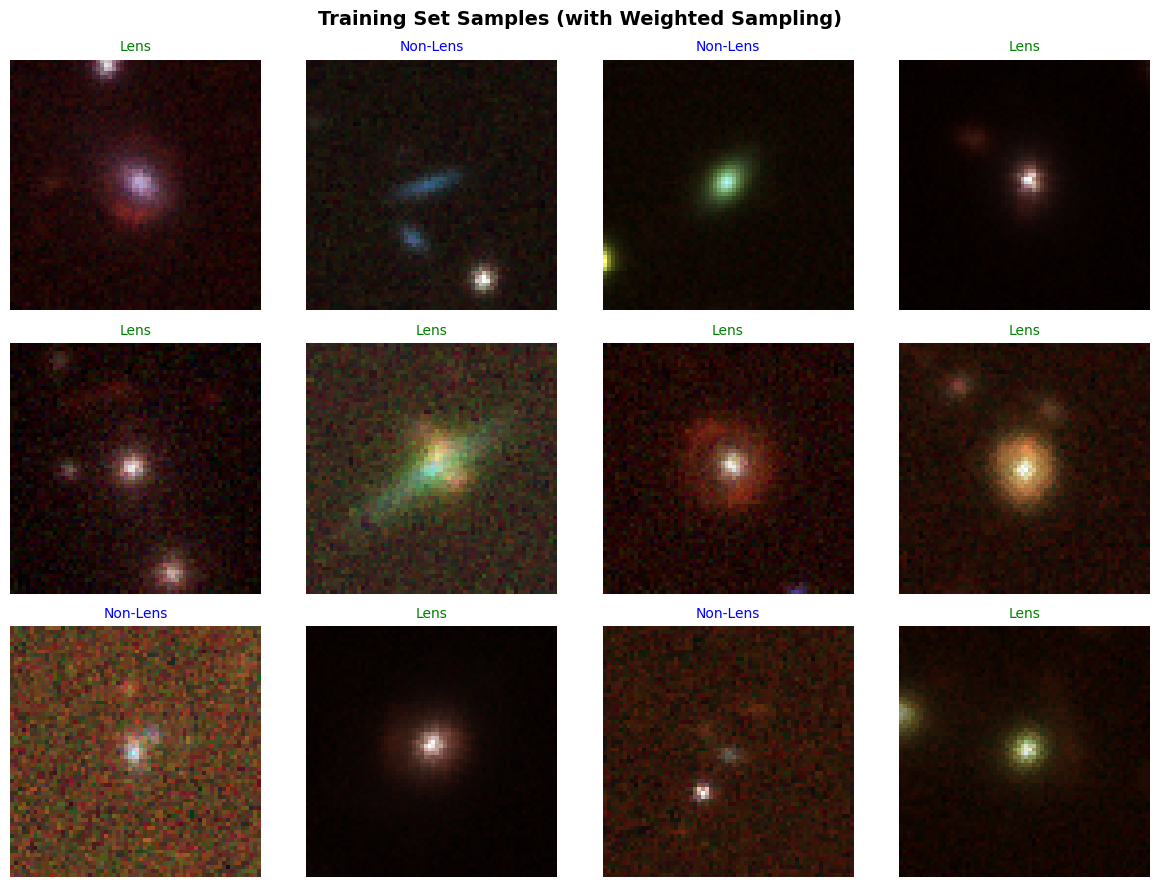

In [13]:
# ============================================================
# Visualize Sample Images
# ============================================================

def plot_sample_images(loader, num_samples=12, title="Sample Images"):
    """Plot sample images from a dataloader"""
    images, labels = next(iter(loader))
    
    # Denormalize images (from ImageNet normalization)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images_denorm = images * std + mean
    images_denorm = torch.clamp(images_denorm, 0, 1)
    
    num_samples = min(num_samples, len(images))
    cols = 4
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    class_names = ['Non-Lens', 'Lens']
    
    for i in range(num_samples):
        img = images_denorm[i].permute(1, 2, 0).numpy()
        label = labels[i].item()
        
        axes[i].imshow(img)
        color = 'green' if label == 1 else 'blue'
        axes[i].set_title(f'{class_names[label]}', fontsize=10, color=color)
        axes[i].axis('off')
    
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("🖼️ Sample Training Images:")
plot_sample_images(train_loader, num_samples=12, title="Training Set Samples (with Weighted Sampling)")

In [14]:
# ============================================================
# Training Functions
# ============================================================

def train_epoch(model, loader, optimizer, criterion, device, prior_weight, opt_weight):
    model.train()
    total_loss, total_bce, total_prior, total_opt = 0, 0, 0, 0
    correct, total = 0, 0
    
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # (B,) -> (B, 1)
        
        optimizer.zero_grad()
        logits = model(images)
        
        bce_loss = criterion(logits, labels)
        prior_loss = model.get_prior_loss()
        opt_loss = model.get_optimization_loss()
        
        loss = bce_loss + prior_weight * prior_loss + opt_weight * opt_loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_bce += bce_loss.item()
        total_prior += prior_loss.item()
        total_opt += opt_loss.item() if isinstance(opt_loss, torch.Tensor) else opt_loss
        
        # Calculate accuracy
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}', 
            'acc': f'{100*correct/total:.1f}%'
        })
    
    n = len(loader)
    return {
        'loss': total_loss / n,
        'bce_loss': total_bce / n,
        'prior_loss': total_prior / n,
        'opt_loss': total_opt / n,
        'acc': 100 * correct / total,
    }


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc="Validation")
    for images, labels in pbar:
        images = images.to(device)
        labels_float = labels.float().unsqueeze(1).to(device)
        
        logits = model(images)
        loss = criterion(logits, labels_float)
        probs = torch.sigmoid(logits)
        
        total_loss += loss.item()
        preds = (probs > 0.5).float()
        correct += (preds == labels_float).sum().item()
        total += labels.size(0)
        
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy().flatten())
        
        pbar.set_postfix({'acc': f'{100*correct/total:.1f}%'})
    
    # Calculate ROC-AUC
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    return {
        'loss': total_loss / len(loader),
        'acc': 100 * correct / total,
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
    }

print("✅ Training functions defined")

✅ Training functions defined


In [15]:
# ============================================================
# Create Model
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")

# Create model
model = LensFindingClassifier(CONFIG).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
canon_params = sum(p.numel() for p in model.canon_network.parameters() if p.requires_grad)
backbone_params = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)

print(f"\n🏗️  Model created:")
print(f"   Canonicalization: {CONFIG['canon_network']}")
print(f"   Backbone: {CONFIG['backbone']}")
print(f"   Group: {CONFIG['group_type']} with {CONFIG['num_rotations']} rotations")
print(f"\n📊 Parameters:")
print(f"   Canonicalizer: {canon_params:,}")
print(f"   Backbone: {backbone_params:,}")
print(f"   Total: {total_params:,}")

# ============================================================
# Setup Optimizer, Scheduler, and Loss
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=CONFIG["epochs"]
)

# BCEWithLogitsLoss with pos_weight for class imbalance
if CONFIG["use_pos_weight"]:
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    print(f"\n✅ Loss: BCEWithLogitsLoss with pos_weight={pos_weight.item():.4f}")
else:
    criterion = nn.BCEWithLogitsLoss()
    print(f"\n✅ Loss: BCEWithLogitsLoss (no pos_weight)")

print(f"✅ Optimizer: AdamW (lr={CONFIG['lr']}, weight_decay={CONFIG['weight_decay']})")
print(f"✅ Scheduler: CosineAnnealingLR (T_max={CONFIG['epochs']})")

🖥️  Device: cuda


/home/jovyan/.local/lib/python3.11/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  full_mask[mask] = norms.to(torch.uint8)



🏗️  Model created:
   Canonicalization: ESCNNEquivariantNetwork
   Backbone: resnet18
   Group: rotation with 8 rotations

📊 Parameters:
   Canonicalizer: 181,504
   Backbone: 11,177,025
   Total: 11,358,529

✅ Loss: BCEWithLogitsLoss with pos_weight=16.5751
✅ Optimizer: AdamW (lr=0.0001, weight_decay=0.001)
✅ Scheduler: CosineAnnealingLR (T_max=30)


In [16]:
# ============================================================
# Training Loop
# ============================================================

best_auc = 0
history = []

print(f"\n🚀 Starting training for {CONFIG['epochs']} epochs...")
print("="*60)

for epoch in range(CONFIG["epochs"]):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']} | LR: {scheduler.get_last_lr()[0]:.6f}")
    
    # Train
    train_metrics = train_epoch(
        model, train_loader, optimizer, criterion, device,
        CONFIG["prior_weight"], CONFIG["opt_weight"]
    )
    
    # Validate on test set
    val_metrics = validate(model, test_loader, criterion, device)
    
    # Print results
    print(f"  Train: loss={train_metrics['loss']:.4f}, acc={train_metrics['acc']:.2f}%")
    print(f"  Test:  loss={val_metrics['loss']:.4f}, acc={val_metrics['acc']:.2f}%, AUC={val_metrics['auc']:.4f}")
    
    # Save history
    history.append({
        'epoch': epoch + 1,
        'train_loss': train_metrics['loss'],
        'train_acc': train_metrics['acc'],
        'test_loss': val_metrics['loss'],
        'test_acc': val_metrics['acc'],
        'test_auc': val_metrics['auc'],
    })
    
    # Save best model (based on AUC - the evaluation metric)
    if val_metrics['auc'] > best_auc:
        best_auc = val_metrics['auc']
        os.makedirs(CONFIG["save_dir"], exist_ok=True)
        save_path = os.path.join(CONFIG["save_dir"], f"best_lens_finding_{CONFIG['canon_network']}_{CONFIG['backbone']}.pth")
        torch.save({
            'model_state_dict': model.state_dict(),
            'test_auc': best_auc,
            'test_acc': val_metrics['acc'],
            'epoch': epoch + 1,
            'config': CONFIG,
        }, save_path)
        print(f"  ✅ Saved best model (AUC={best_auc:.4f})")
    
    scheduler.step()

print("\n" + "="*60)
print(f"🎉 Training Complete!")
print(f"   Best Test AUC: {best_auc:.4f}")
print("="*60)


🚀 Starting training for 30 epochs...

Epoch 1/30 | LR: 0.000100


Training:   0%|          | 0/951 [00:00<?, ?it/s]

Validation:   0%|          | 0/615 [00:00<?, ?it/s]

  Train: loss=1.7232, acc=64.82%
  Test:  loss=1.1053, acc=48.57%, AUC=0.9475
  ✅ Saved best model (AUC=0.9475)

Epoch 2/30 | LR: 0.000100


Training:   0%|          | 0/951 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/615 [00:00<?, ?it/s]

  Train: loss=0.5256, acc=97.44%
  Test:  loss=0.1649, acc=96.06%, AUC=0.9846

Epoch 30/30 | LR: 0.000000


Training:   0%|          | 0/951 [00:00<?, ?it/s]

Validation:   0%|          | 0/615 [00:00<?, ?it/s]

  Train: loss=0.5236, acc=97.44%
  Test:  loss=0.1524, acc=96.39%, AUC=0.9846

🎉 Training Complete!
   Best Test AUC: 0.9867


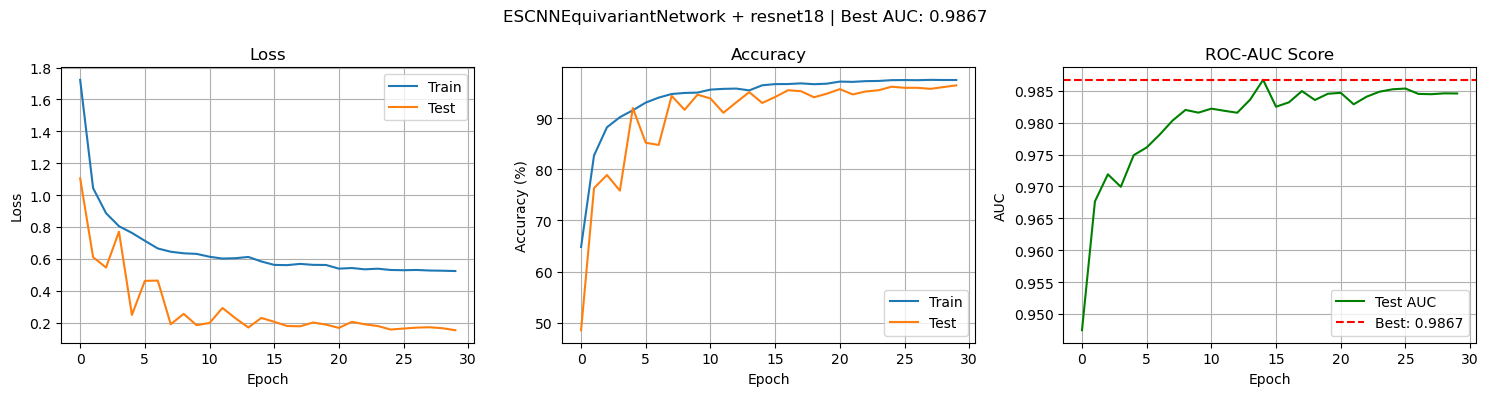

In [17]:
# ============================================================
# Plot Training History
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss plot
axes[0].plot([h['train_loss'] for h in history], label='Train')
axes[0].plot([h['test_loss'] for h in history], label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot([h['train_acc'] for h in history], label='Train')
axes[1].plot([h['test_acc'] for h in history], label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

# AUC plot
axes[2].plot([h['test_auc'] for h in history], label='Test AUC', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].set_title('ROC-AUC Score')
axes[2].legend()
axes[2].grid(True)
axes[2].axhline(y=best_auc, color='red', linestyle='--', label=f'Best: {best_auc:.4f}')
axes[2].legend()

plt.suptitle(f"{CONFIG['canon_network']} + {CONFIG['backbone']} | Best AUC: {best_auc:.4f}")
plt.tight_layout()
plt.show()

📥 Loading best model...


/tmp/ipykernel_567/3217284323.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


   Loaded model from epoch 15 with AUC: 0.9867


Validation:   0%|          | 0/615 [00:00<?, ?it/s]


🎯 FINAL TEST RESULTS
   Test Accuracy: 92.96%
   Test AUC: 0.9867


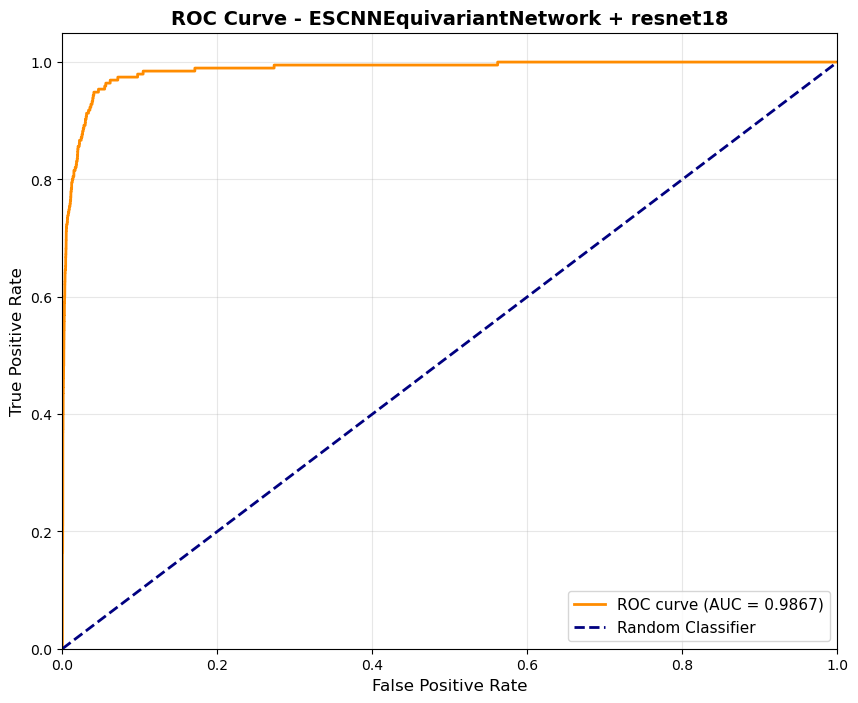


✅ ROC curve saved to 'roc_curve_equiadapt.png'


In [ ]:
# ============================================================
# Final Evaluation - Load Best Model
# ============================================================

print("📥 Loading best model...")
checkpoint_path = os.path.join(CONFIG["save_dir"], f"best_lens_finding_{CONFIG['canon_network']}_{CONFIG['backbone']}.pth")
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"   Loaded model from epoch {checkpoint['epoch']} with AUC: {checkpoint['test_auc']:.4f}")

# Final evaluation
final_metrics = validate(model, test_loader, criterion, device)

print(f"\n" + "="*60)
print(f"🎯 FINAL TEST RESULTS")
print(f"="*60)
print(f"   Test Accuracy: {final_metrics['acc']:.2f}%")
print(f"   Test AUC: {final_metrics['auc']:.4f}")
print(f"="*60)

# ============================================================
# Plot ROC Curve
# ============================================================

plt.figure(figsize=(10, 8))
plt.plot(final_metrics['fpr'], final_metrics['tpr'], 
         color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {final_metrics["auc"]:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {CONFIG["canon_network"]} + {CONFIG["backbone"]}', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ ROC curve saved to 'roc_curve.png'")

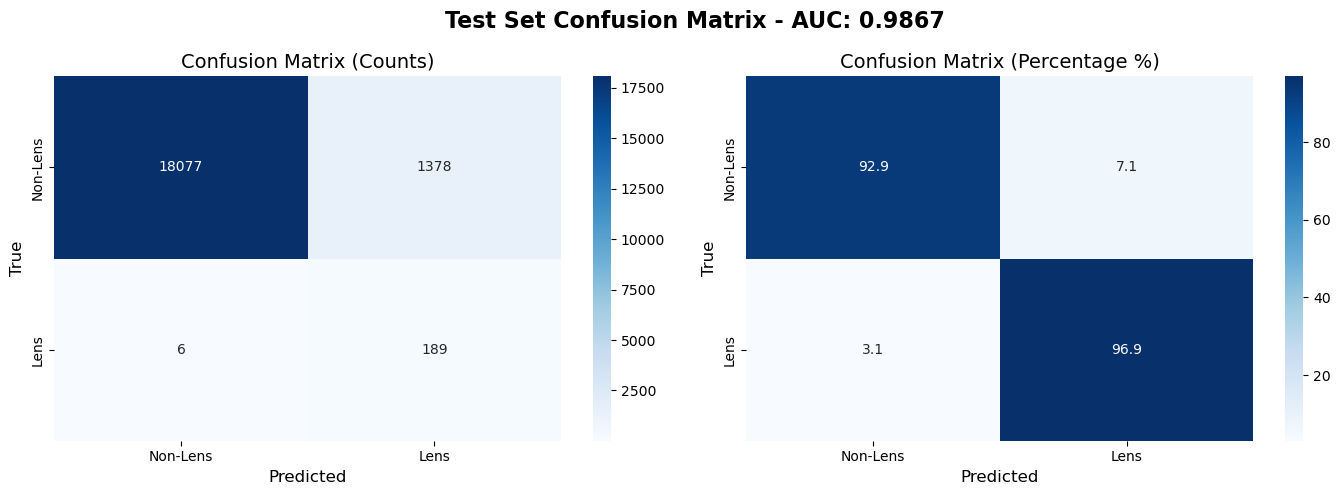


📊 Classification Report:
              precision    recall  f1-score   support

    Non-Lens     0.9997    0.9292    0.9631     19455
        Lens     0.1206    0.9692    0.2145       195

    accuracy                         0.9296     19650
   macro avg     0.5601    0.9492    0.5888     19650
weighted avg     0.9909    0.9296    0.9557     19650



In [19]:
# ============================================================
# Confusion Matrix and Classification Report
# ============================================================

# Get predictions at threshold 0.5
predictions = (final_metrics['probs'] > 0.5).astype(int)
labels = final_metrics['labels']

# Confusion matrix
cm = confusion_matrix(labels, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_names = ['Non-Lens', 'Lens']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_title('Confusion Matrix (Percentage %)', fontsize=14)

plt.suptitle(f'Test Set Confusion Matrix - AUC: {final_metrics["auc"]:.4f}', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification Report
print("\n📊 Classification Report:")
print("="*60)
print(classification_report(labels, predictions, target_names=class_names, digits=4))

In [20]:
# ============================================================
# Prediction Function
# ============================================================

def predict_lens(model, image_path, device, transform=None):
    """Predict whether an image contains a gravitational lens
    
    Args:
        model: Trained model
        image_path: Path to .npy file
        device: torch device
        transform: Normalization transform
        
    Returns:
        probability: Probability of being a lens (0-1)
    """
    # Load image
    image = np.load(image_path)
    image_tensor = torch.tensor(image, dtype=torch.float32)
    
    # Apply normalization
    if transform is None:
        transform = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )
    image_tensor = transform(image_tensor)
    
    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probability = torch.sigmoid(output).item()
    
    return probability


# Save the final model
final_model_path = 'lens_finding_equiadapt.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CONFIG,
    'test_auc': final_metrics['auc'],
    'test_acc': final_metrics['acc'],
}, final_model_path)

print(f"✅ Model saved to '{final_model_path}'")

# ============================================================
# Final Summary
# ============================================================

print("\n" + "="*70)
print("                        FINAL MODEL SUMMARY")
print("="*70)
print(f"\n🏗️  Architecture:")
print(f"    Canonicalization Network: {CONFIG['canon_network']}")
print(f"    Backbone: {CONFIG['backbone']}")
print(f"    Group Type: {CONFIG['group_type']} ({CONFIG['num_rotations']} rotations)")

print(f"\n📊 Dataset:")
print(f"    Training samples: {len(train_loader.dataset)}")
print(f"    Test samples: {len(test_loader.dataset)}")
print(f"    Class imbalance handled with: WeightedRandomSampler + pos_weight in BCE")

print(f"\n🎯 Performance:")
print(f"    Test Accuracy: {final_metrics['acc']:.2f}%")
print(f"    Test ROC-AUC: {final_metrics['auc']:.4f}")

print("\n" + "="*70)
print("                         EVALUATION COMPLETE")
print("="*70)

✅ Model saved to 'lens_finding_equiadapt.pth'

                        FINAL MODEL SUMMARY

🏗️  Architecture:
    Canonicalization Network: ESCNNEquivariantNetwork
    Backbone: resnet18
    Group Type: rotation (8 rotations)

📊 Dataset:
    Training samples: 30405
    Test samples: 19650
    Class imbalance handled with: WeightedRandomSampler + pos_weight in BCE

🎯 Performance:
    Test Accuracy: 92.96%
    Test ROC-AUC: 0.9867

                         EVALUATION COMPLETE
